In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(os.path.join('..')))
from src.engine import simulate_first_passage_times

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
mu_test = 0.5     
sigma_test = 1.2  
n_pop = 20000

fpt_results = simulate_first_passage_times(mu=mu_test, sigma=sigma_test, n_neurons=n_pop)

# Nan removed, neurons that did not spike
fpt_valid = fpt_results[~np.isnan(fpt_results)]

mean_fpt = np.mean(fpt_valid)
firing_rate = 1000.0 / mean_fpt

print(f"Average spike time: {mean_fpt:.2f} ms")
print(f"Estimated firing rate: {firing_rate:.2f} Hz")

Average spike time: 2.21 ms
Estimated firing rate: 452.81 Hz


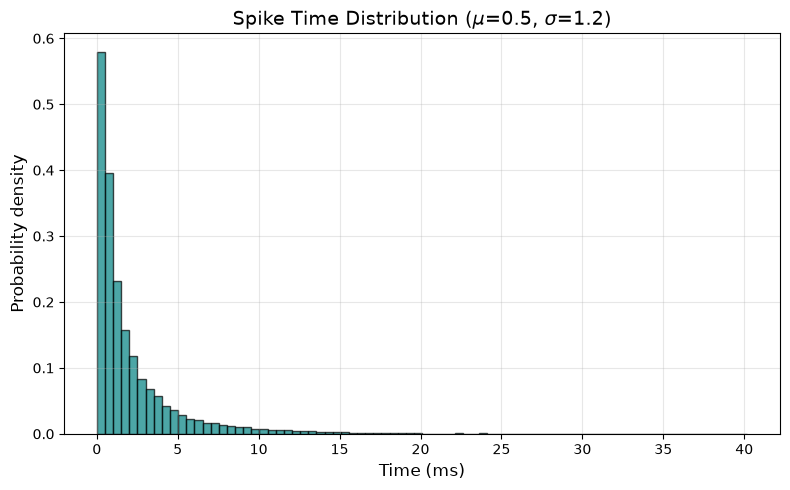

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(fpt_valid, bins=80, density=True, color='teal', edgecolor='black', alpha=0.7)

plt.title(rf"")
plt.title(rf"Spike Time Distribution ($\mu$={mu_test}, $\sigma$={sigma_test})", fontsize=14)
plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Probability density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9959/403767132.py:49: SyntaxWarning: invalid escape sequence '\s'
  color=color, linewidth=2, label=f'$\sigma = {sigma}$')
/tmp/ipykernel_9959/403767132.py:54: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("Average Input Current ($\mu$)", fontsize=12)
/tmp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Calculating CV for sigma=0.25: 100%|██████████| 30/30 [00:15<00:00,  1.89it/s]


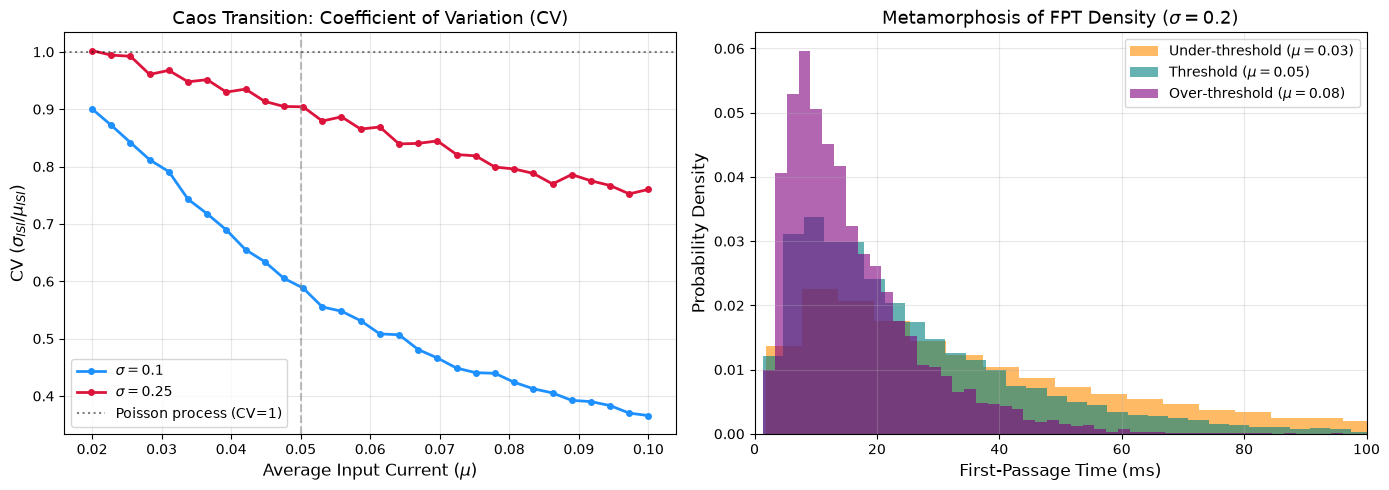

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from tqdm import tqdm

%load_ext autoreload
%autoreload 2
sys.path.append(os.path.abspath(os.path.join('..')))
from src.engine import simulate_first_passage_times

# Parameters
mu_values = np.linspace(0.02, 0.1, 30)
sigma_values = [0.1, 0.25]
n_pop = 10000
t_max = 3000.0

cv_results = {sig: [] for sig in sigma_values}

# Coefficient of Variation calculation
for sigma in sigma_values:
    for mu in tqdm(mu_values, desc=f"Calculating CV for sigma={sigma}"):
        fpt = simulate_first_passage_times(mu, sigma, n_neurons=n_pop, t_max=t_max)
        fpt_valid = fpt[~np.isnan(fpt)]
        
        if len(fpt_valid) > 10: # check if data are enough to compute CV
            cv = np.std(fpt_valid) / np.mean(fpt_valid)
        else:
            cv = np.nan
        cv_results[sigma].append(cv)


# Hystograms for different mu values at a fixed sigma
sigma_hist = 0.2
mu_samples = [0.03, 0.05, 0.08] # under-threshold, threshold, over-threshold
hist_data = []

for mu in mu_samples:
    fpt = simulate_first_passage_times(mu, sigma_hist, n_neurons=n_pop, t_max=t_max)
    hist_data.append(fpt[~np.isnan(fpt)])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


colors = ['dodgerblue', 'crimson']
for sigma, color in zip(sigma_values, colors):
    ax1.plot(mu_values, cv_results[sigma], marker='o', markersize=4, 
             color=color, linewidth=2, label=f'$\sigma = {sigma}$')

ax1.axvline(x=0.05, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Poisson process (CV=1)')
ax1.set_title("Caos Transition: Coefficient of Variation (CV)", fontsize=13)
ax1.set_xlabel("Average Input Current ($\mu$)", fontsize=12)
ax1.set_ylabel("CV ($\sigma_{ISI} / \mu_{ISI}$)", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)


colors_hist = ['darkorange', 'teal', 'purple']
labels_hist = ['Under-threshold ($\mu=0.03$)', 'Threshold ($\mu=0.05$)', 'Over-threshold ($\mu=0.08$)']

for data, color, label in zip(hist_data, colors_hist, labels_hist):
    ax2.hist(data, bins=60, density=True, alpha=0.6, color=color, label=label)

ax2.set_title(f"Metamorphosis of FPT Density ($\sigma = {sigma_hist}$)", fontsize=13)
ax2.set_xlabel("First-Passage Time (ms)", fontsize=12)
ax2.set_ylabel("Probability Density", fontsize=12)
ax2.set_xlim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()